## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [3]:
years = range(2009, 2024)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2009 | (38856, 102)
Year: 2010 | (38856, 102)
Year: 2011 | (38856, 102)
Year: 2012 | (38856, 102)
Year: 2013 | (38856, 102)
Year: 2014 | (38856, 102)
Year: 2015 | (38856, 102)
Year: 2016 | (38856, 102)
Year: 2017 | (38856, 102)
Year: 2018 | (38856, 102)
Year: 2019 | (38856, 102)
Year: 2020 | (38856, 102)
Year: 2021 | (38856, 102)
Year: 2022 | (38856, 102)
Year: 2023 | (38856, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-5.304615,-4.007000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,15.971640,64.969894,107.176805,481.184053,495.120838,495.120838,-10.23,-0.01,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN
1,0,2009-02,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-5.618571,-5.169643,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,7.658397,3.097472,16.418973,251.758902,709.555965,214.435127,-11.15,2.09,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN
2,0,2009-03,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2009,3,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-12.568065,-6.814516,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,10.017922,57.903012,92.262089,300.994896,1020.111546,310.555581,-32.81,2.37,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN
3,0,2009-04,EL6,κεντρικη ελλαδα,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,21.15549,39.67943,2,3,3,2009,4,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-10.530000,-2.975333,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.618571,-12.568065,-10.530000,-4.745808,-5.169643,-6.814516,-2.975333,4.663111,45.037188,73.646778,139.893334,1160.004880,139.893334,-11.13,5.69,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,174

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

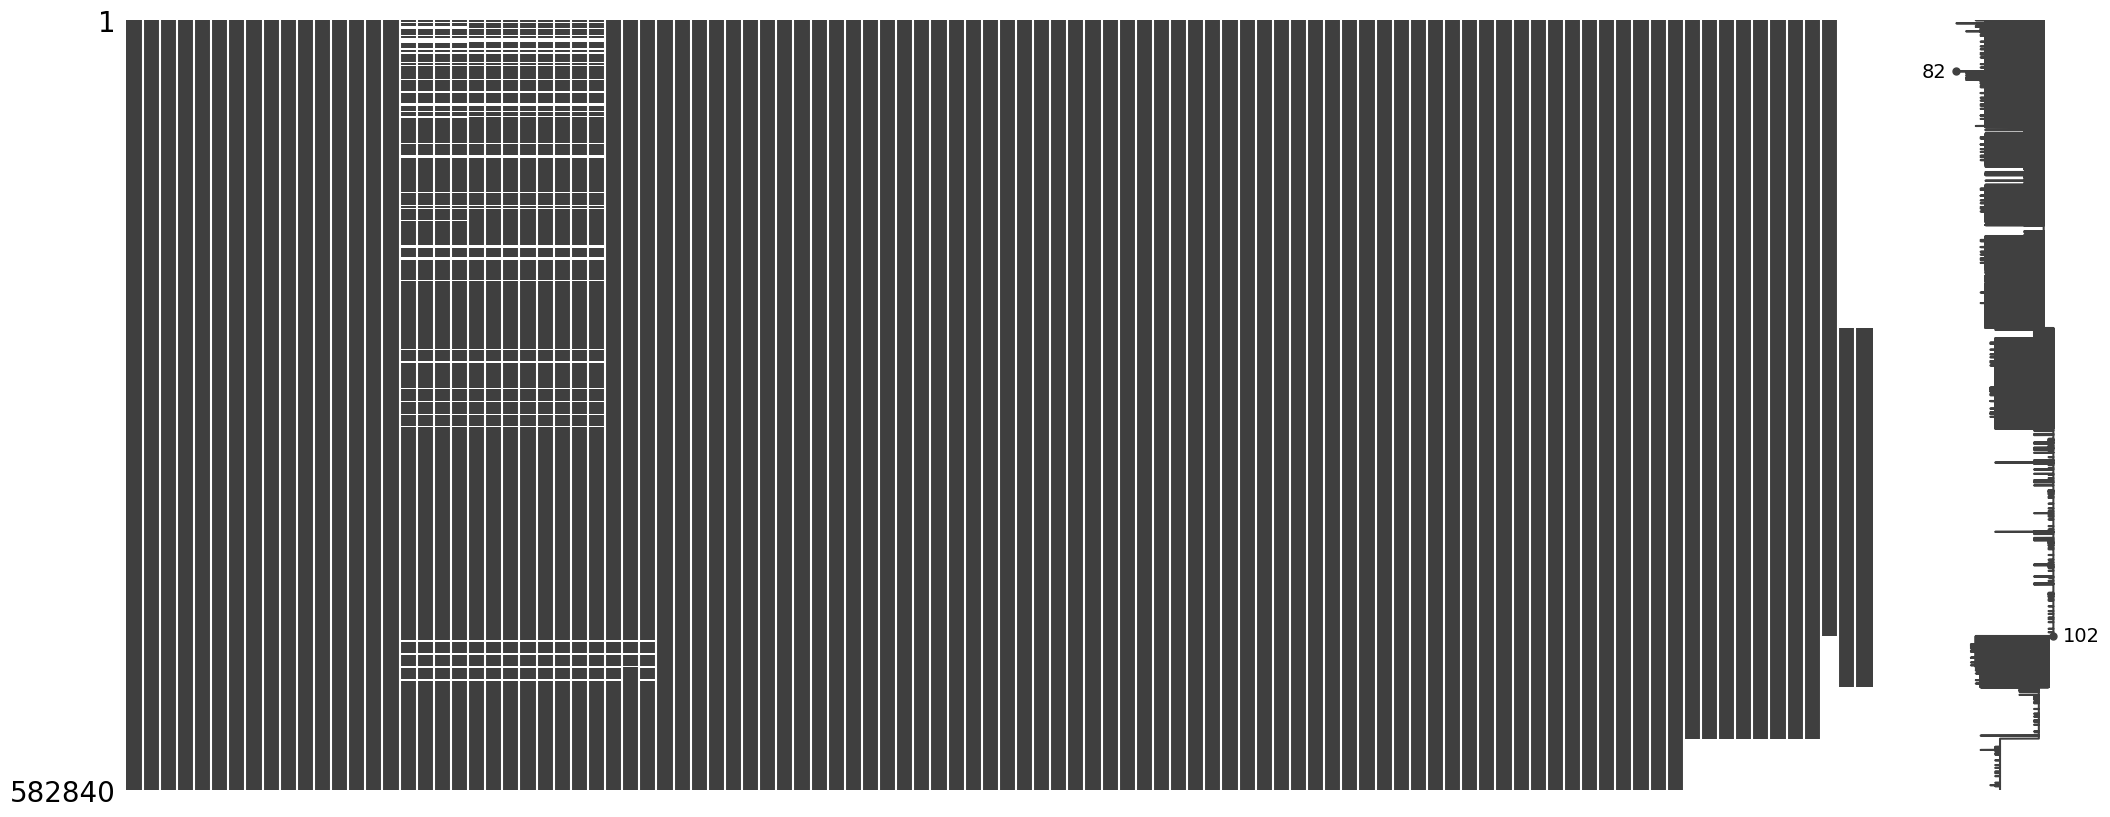

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,7.4175
17,ndmi,7.4175
18,ndwi,7.4175
19,ndbi,7.4175
20,ndvi_mean,6.7399
...,...,...
97,F_Y_GE65,6.6667
98,F_TOTAL,6.6667
99,MIO_EUR,20.0000
100,L_TOTAL,53.3333


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_NAME', 'NUTS1_ID', 'rainfall_acc']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.187000,-4.187000,-4.720714,-1.060968,4.579333,-5.304615,-5.304615,-5.618571,-12.568065,-10.530000,-4.007000,-4.745808,-5.169643,-6.814516,-2.975333,-10.23,-0.01,15.971640,64.969894,107.176805,481.184053,495.120838,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,2,3,3
1,2009-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,2,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.720714,-4.187000,-4.720714,-1.060968,4.579333,-5.618571,-5.304615,-5.618571,-12.568065,-10.530000,-5.169643,-4.745808,-5.169643,-6.814516,-2.975333,-11.15,2.09,7.658397,3.097472,16.418973,251.758902,709.555965,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,2,3,3
2,2009-03,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,3,2009,0.123309,0.782576,0.746893,-0.782576,0.105394,0.773997,0.742390,-0.773997,0.029984,0.038986,0.045763,0.038986,-1.060968,-4.187000,-4.720714,-1.060968,4.579333,-12.568065,-5.304615,-5.618571,-12.568065,-10.530000,-6.814516,-4.745808,-5.169643,-6.814516,-2.975333,-32.81,2.37,10.017922,57.903012,92.262089,300.994896,1020.111546,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,2,3,3
3,2009-04,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.67943,4,2009,0.319318,0.853560,0.745776,-0.853560,0.089676,0.300205,0.221905,-0.300205,0.051067,0.043001,0.012628,0.043001,4.579333,-4.187000,-4.720714,-1.060968,4.579333,-10.530000,-5.304615,-5.618571,-12.568065,-10.530000,-2.975333,-4.745808,-5.169643,-6.814516,-2.975333,-11.13,5.69,4.663111,45.037188,73.646778,139.893334,1160.004880,7.250,21.50,31.159420,1197.630236,37.0,-32.0,69.0,3.0,20.333333,20.833333,-8.166667,2843.0,495.0,56.0,67.458711,1346.0,223.0,330.0,1019.0,20057.653131,722.827790,34,176.440719,1574.522145,141.293561,0.000000,2.204379,31,97,36,95.0,30,97,12,12,1,6,7,2,0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,2,3,3
4,2009-05,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",καλαμπακας,0,21.15549,39.679

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2010 | Month: 1
Year: 2010 | Month: 2
Year: 2010 | Month: 3
Year: 2010 | Month: 4
Year: 2010 | Month: 5
Year: 2010 | Month: 6
Year: 2010 | Month: 7
Year: 2010 | Month: 8
Year: 2010 | Month: 9
Year: 2010 | Month: 10
Year: 2010 | Month: 11
Year: 2010 | Month: 12
Year: 2011 | Month: 1
Year: 2011 | Month: 2
Year: 2011 | Month: 3
Year: 2011 | Month: 4
Year: 2011 | Month: 5
Year: 2011 | Month: 6
Year: 2011 | Month: 7
Year: 2011 | Month: 8
Year: 2011 | Month: 9
Year: 2011 | Month: 10
Year: 2011 | Month: 11
Year: 2011 | Month: 12
Year: 2012 | Month: 1
Year: 2012 | Month: 2
Year: 2012 | Month: 3
Year: 2012 | Month: 4
Year: 2012 | Month: 5
Year: 2012 | Month: 6
Year: 2012 | Month: 7
Year: 2012 | Month: 8
Year: 2012 | Month: 9
Year: 2012 | Month: 10
Year: 2012 | Month: 11
Year: 2012 | Month: 12
Year: 2013 | Month: 1
Year: 2013 | Month: 2
Year: 2013 | Month: 3
Year: 2013 | Month: 4
Year: 2013 | Month: 5
Year: 2013 | Month: 6
Year: 2013 | Month: 7
Year: 2013 | Month: 8
Year: 2013 | Month: 9
Y

In [19]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2017)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
310848,2017-01,"καρδιτσα, τρικαλα",0,21.15549,39.67943,1,2017,0.511348,0.094143,-0.505720,-0.094143,0.541273,0.233714,-0.466527,-0.233714,0.097932,0.167094,0.065924,0.167094,-6.297097,-6.297097,-0.759286,6.835806,15.912667,-3.650000,-3.65,0.787143,1.475806,2.012,-4.973548,-4.973548,0.013929,4.155806,8.962333,-16.69,-2.67,8.588974,72.528639,148.749361,266.252725,266.258185,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,96,36,92.0,30,96,12,12,1,6,7,2,0,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
310849,2017-02,"καρδιτσα, τρικαλα",0,21.15549,39.67943,2,2017,0.103714,0.616766,-0.140203,-0.616766,0.145503,0.723925,-0.153906,-0.723925,0.134722,0.111105,0.102393,0.111105,-0.759286,-6.297097,-0.759286,6.835806,15.912667,0.787143,-3.65,0.787143,1.475806,2.012,1.321429,-4.973548,0.013929,4.155806,8.962333,-3.49,3.97,4.597506,45.685285,80.403046,128.730165,394.988350,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,96,36,92.0,30,96,12,12,1,6,7,2,0,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
310850,2017-03,"καρδιτσα, τρικαλα",0,21.15549,39.67943,3,2017,0.111170,0.591415,-0.140788,-0.591415,0.154305,0.697535,-0.157208,-0.697535,0.136588,0.110340,0.105372,0.110340,6.835806,-6.297097,-0.759286,6.835806,15.912667,1.475806,-3.65,0.787143,1.475806,2.012,4.155806,-4.973548,0.013929,4.155806,8.962333,-1.13,17.97,3.760153,2.977481,23.615661,114.963480,511.553101,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,96,36,92.0,30,96,12,12,1,6,7,2,0,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
310851,2017-04,"καρδιτσα, τρικαλα",0,21.15549,39.67943,4,2017,0.367847,0.100927,-0.358295,-0.100927,0.399148,0.204380,-0.361570,-0.204380,0.152782,0.097540,0.121815,0.097540,15.912667,-6.297097,-0.759286,6.835806,15.912667,2.012000,-3.65,0.787143,1.475806,2.012,8.962333,-4.973548,0.013929,4.155806,8.962333,-1.35,21.95,2.566085,3.844025,19.474104,76.982546,588.535647,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,31,96,36,92.0,30,96,12,12,1,6,7,2,0,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
310852,2017-05,"καρδιτσα, τρικαλα",0,21.15549,39.67943,5,2017,0.461548,0.102797,-0.445047,-0.102797,0.489305,0.185112,-0.444246,-0.185112,0.113857,0.086972,0.08

In [20]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2018)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
310848,0,EL61,EL611,καλαμπακας,2018,1,21.15549,39.67943,0.217977,0.590945,-0.248245,-0.590945,0.311025,0.633913,-0.269263,-0.633913,0.132428,0.063925,0.092908,0.063925,-1.551290,-0.742903,-0.877143,1.356452,13.425333,-1.210000,-0.771538,-1.17,1.891905,4.371333,-1.380645,-0.757221,-1.023571,1.624178,8.898333,-9.27,7.45,13.031919,49.610618,176.695387,248.380797,141.025684,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
314086,0,EL61,EL611,καλαμπακας,2018,2,21.15549,39.67943,0.050618,0.727163,-0.038382,-0.727163,0.078627,0.671401,-0.046878,-0.671401,0.068174,0.105025,0.072872,0.105025,-0.742903,-0.742903,-0.877143,1.356452,13.425333,-0.771538,-0.771538,-1.17,1.891905,4.371333,-0.608077,-0.757221,-1.023571,1.624178,8.898333,-6.65,3.69,4.549216,0.000000,39.121450,140.434564,636.487028,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
317324,0,EL61,EL611,καλαμπακας,2018,3,21.15549,39.67943,0.213563,0.469112,-0.240285,-0.469112,0.221468,0.536161,-0.211470,-0.536161,0.162040,0.153030,0.123715,0.153030,-0.877143,-0.742903,-0.877143,1.356452,13.425333,-1.170000,-0.771538,-1.17,1.891905,4.371333,-1.023571,-0.757221,-1.023571,1.624178,8.898333,-9.07,3.01,17.695048,88.378805,179.910541,495.461344,924.286141,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
320562,0,EL61,EL611,καλαμπακας,2018,4,21.15549,39.67943,0.144340,0.623390,-0.173428,-0.623390,0.204482,0.635318,-0.201061,-0.635318,0.152127,0.127329,0.118561,0.127329,1.356452,-0.742903,-0.877143,1.356452,13.425333,1.891905,-0.771538,-1.17,1.891905,4.371333,2.083810,-0.757221,-1.023571,1.624178,8.898333,-9.07,4.75,9.283842,40.126554,167.215111,278.055258,964.119898,9.916667,21.166667,40.705128,965.738844,36.0,-16.0,52.0,-1.0,16.333333,21.0,-3.333333,1906.0,495.0,14.0,93.819631,1164.0,136.0,176.0,797.0,31,36,30,12,12,1,6,7,20057.653131,722.82779,34,176.440719,1574.522145,141.293561,0.0,2.204379,15852.0,71874.0,30187.0,117913.0,15049.0,69528.0,36104.0,120681.0,2497.86,7816.0,7614.0,2,3,3
323800,0,EL61,EL611,καλαμπακας,2018,5,21.15549,39.67943,0.288243,0.315041,-0.310199,-0.315041,0.301347,0.424341,-0.299457,-0.424341,0.165512,0.156302,0.120162,0.156302,13.425333,-0.742903,-0.877143,1.356452,13.425333,4.371333,-0.771538,-1.

<Axes: >

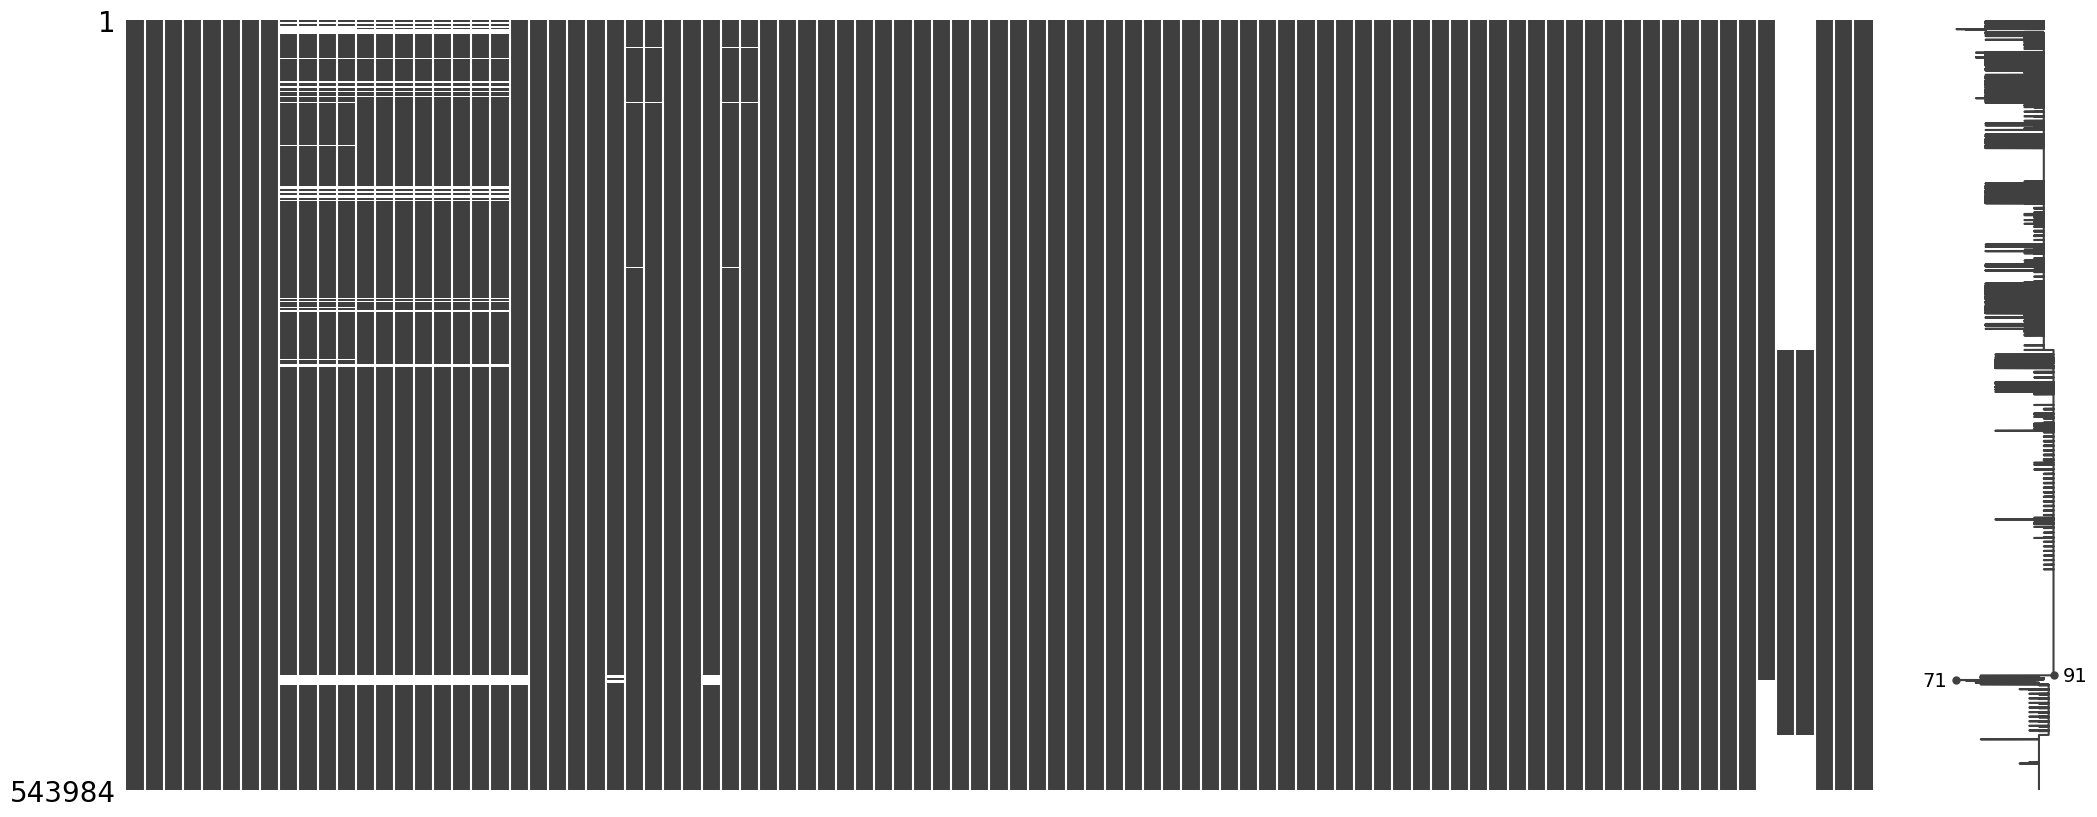

In [21]:
missingno.matrix(dataset_operational)

In [22]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,5.9393
9,ndmi,5.9393
10,ndwi,5.9393
11,ndbi,5.9393
12,ndvi_mean,5.3163
...,...,...
32,lst_feb_mean,0.0485
33,lst_mar_mean,0.0022
85,mio_eur,14.2857
86,l_total,50.0000


In [23]:
# dataset_monthly.cases.sum()

In [24]:
# dataset_operational.cases.sum()

In [25]:
years = dataset_operational.year.unique().tolist()

In [26]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)